In [5]:
#  CHSH Inequality Violation — Qiskit Aer Simulation
""" 
  What this code does:
  We prepare two entangled qubits in the Bell state |Φ+⟩ and measure them in four different angle combinations. 
  If quantum mechanics is right, the combined result S should exceed 2 — 
  something no classical "hidden variable" theory can ever achieve.
  
  Classical (LHV) prediction : |S| ≤ 2.000
  Quantum mechanics predicts  : |S| = 2√2 ≈ 2.828  (Tsirelson's bound)
  -------------------------------------------------------------------------------------------
 
  Dependencies
  Run once to install if you haven't already:
#   pip install qiskit qiskit-aer pylatexenc
  In a Jupyter / Kaggle environment you can use the magic:
#   %pip install qiskit qiskit-aer pylatexenc
"""
 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
 
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

In [6]:
# SECTION 1 — Measurement Settings
# ------------------------------------------------------------------------------------
"""
 The CHSH test uses four angle-pair measurements on Alice's and Bob's qubits.

   Alice's angles: a₀ = 0  (we will call it "Z"),  a₁ = π/2  ("X")
   Bob's   angles: b₀ = π/4 ("Z"),            b₁ = 3π/4 ("X")

 Measuring a qubit along direction θ in the Bloch sphere's XZ-plane is done by rotating the qubit backwards (Ry(−θ)) 
 and then measuring in the Z basis.

 Expected correlation for the Bell state |Φ+⟩:
   E(a, b) = cos(a − b)

 CHSH parameter:
   S = E(ZZ) − E(ZX) + E(XZ) + E(XX)
 ---------------------------------------------------------------------------------------
"""
 
ALICE = {'Z': 0.0,       'X': np.pi / 2}
BOB   = {'Z': np.pi / 4, 'X': 3 * np.pi / 4}
 
# Four measurement configurations: (Alice's angle, Bob's angle)
SETTINGS = {
    'ZZ': (ALICE['Z'], BOB['Z']),   # 0     vs π/4
    'ZX': (ALICE['Z'], BOB['X']),   # 0     vs 3π/4
    'XZ': (ALICE['X'], BOB['Z']),   # π/2   vs π/4
    'XX': (ALICE['X'], BOB['X']),   # π/2   vs 3π/4
}
 
print("  CHSH Inequality Violation  —  Qiskit Aer Simulation")
print("-" * 56)
print(f"  Bell state prepared: |Φ+⟩ = (1/√2)(|00⟩ + |11⟩)\n")
print(f"  {'Config':<8} {'θ_Alice (rad)':<18} {'θ_Bob (rad)'}")
print("  " + "─" * 40)
for label, (ta, tb) in SETTINGS.items():
    print(f"  {label:<8} {ta:<18.4f} {tb:.4f}")

  CHSH Inequality Violation  —  Qiskit Aer Simulation
--------------------------------------------------------
  Bell state prepared: |Φ+⟩ = (1/√2)(|00⟩ + |11⟩)

  Config   θ_Alice (rad)      θ_Bob (rad)
  ────────────────────────────────────────
  ZZ       0.0000             0.7854
  ZX       0.0000             2.3562
  XZ       1.5708             0.7854
  XX       1.5708             2.3562


In [7]:
# SECTION 2 — Circuit Construction
# -----------------------------------------------------------------------------
"""
 Each circuit follows three steps:

   1. Entangle: H on qubit 0 -> CNOT -> produces |Φ+⟩
   2. Rotate  : Apply Ry(−θ) to each qubit to pick the measurement direction
   3. Measure : Standard Z-basis measurement

 We skip the Ry gate when θ = 0 (no rotation needed for the Z basis).
 -----------------------------------------------------------------------------------
"""
 
def build_circuit(label: str, theta_alice: float, theta_bob: float) -> QuantumCircuit:
    """
    Build one CHSH measurement circuit.
 
    Parameters
    ----------
    label       : short name like 'ZZ', 'XZ', etc.
    theta_alice : Alice's measurement angle in radians
    theta_bob   : Bob's measurement angle in radians
 
    Returns
    -------
    """
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(2, 'c')
    qc = QuantumCircuit(qr, cr, name=f'CHSH_{label}')
 
    # Creating Bell state |Φ+⟩
    qc.h(qr[0])          # |0⟩ → (|0⟩ + |1⟩)/√2
    qc.cx(qr[0], qr[1])  # entangle: now (|00⟩ + |11⟩)/√2
    qc.barrier()
    # Rotating into measurement basis (skip if angle is zero)
    if not np.isclose(theta_alice, 0.0):
        qc.ry(-theta_alice, qr[0])
    if not np.isclose(theta_bob, 0.0):
        qc.ry(-theta_bob, qr[1])
    qc.barrier()
 
    # Measuring both qubits
    qc.measure(qr, cr)
 
    return qc
  
# all four circuits at once
circuits = {
    label: build_circuit(label, ta, tb)
    for label, (ta, tb) in SETTINGS.items()
}
print("\n  All four CHSH circuits built successfully.")


  All four CHSH circuits built successfully.


In [8]:
# SECTION 3 — Run on the Aer Simulator
# ---------------------------------------------------------------
 
SHOTS     = 8192           # more shots decreases lower statistical noise
simulator = AerSimulator()
 
print(f"\n  Backend : {simulator.name}")
print(f"  Shots   : {SHOTS}")
print("\n  Transpiling and running all circuits -")
 
circuit_list   = list(circuits.values())
circuit_labels = list(circuits.keys())
 
transpiled = transpile(circuit_list, simulator)
job        = simulator.run(transpiled, shots=SHOTS)
result     = job.result()
 
# raw measurement counts (indexed by label)
raw_counts = {
    label: result.get_counts(i)
    for i, label in enumerate(circuit_labels)
}
 
print("\n  Raw measurement counts (bitstring: count):")
for label, cnts in raw_counts.items():
    print(f"  {label}: {cnts}")


  Backend : aer_simulator
  Shots   : 8192

  Transpiling and running all circuits -

  Raw measurement counts (bitstring: count):
  ZZ: {'00': 3514, '11': 3441, '01': 615, '10': 622}
  ZX: {'01': 3530, '10': 3512, '11': 586, '00': 564}
  XZ: {'00': 3540, '11': 3552, '10': 534, '01': 566}
  XX: {'01': 606, '11': 3475, '00': 3536, '10': 575}


In [9]:
# SECTION 4 — Compute Expectation Values E(a, b)
# ----------------------------------------------------------------------------------------------
"""
 For each measurement outcome we assign an eigenvalue based on parity:

   '00' → (+1)(+1) = +1   (both qubits agree)
   '01' → (+1)(−1) = −1   (disagree)
   '10' → (−1)(+1) = −1   (disagree)
   '11' → (−1)(−1) = +1   (both qubits agree)

 So: eigenvalue = +1 if bits match, −1 if they differ.
 # Qiskit convention: the rightmost character in the bitstring = qubit 0.
----------------------------------------------------------------------------
"""
 
def expectation_value(counts: dict, shots: int) -> float:
    """
    Compute ⟨A⊗B⟩ from a measurement counts dictionary. 
    Returns a float in [−1, +1].
    """
    total = 0.0
    for bitstring, count in counts.items():
        bits   = bitstring.replace(' ', '')        # strip any internal spaces
        parity = +1 if bits[0] == bits[-1] else -1  # same bits → +1, different → −1
        total += parity * count
    return total / shots
  
E = {label: expectation_value(raw_counts[label], SHOTS) for label in circuit_labels}
 
print("\n  Expectation values  E(a, b) = ⟨A ⊗ B⟩:")
print(f"\n  {'Label':<8} {'Simulated':>12} {'Analytical':>12} {'Residual':>10}")
print("  " + "─" * 46)
for label in circuit_labels:
    ta, tb    = SETTINGS[label]
    theory    = np.cos(ta - tb)
    residual  = E[label] - theory
    print(f"  {label:<8} {E[label]:>+12.5f} {theory:>+12.5f} {residual:>+10.5f}")


  Expectation values  E(a, b) = ⟨A ⊗ B⟩:

  Label       Simulated   Analytical   Residual
  ──────────────────────────────────────────────
  ZZ           +0.69800     +0.70711   -0.00911
  ZX           -0.71924     -0.70711   -0.01213
  XZ           +0.73145     +0.70711   +0.02434
  XX           +0.71167     +0.70711   +0.00456


In [14]:
# SECTION 5 — The CHSH Parameter S
# -------------------------------------------------------------------------
"""
 S = E(ZZ) − E(ZX) + E(XZ) + E(XX)

 Any classical local hidden-variable (LHV) model must satisfy |S| ≤ 2.
 Quantum mechanics (for the optimal Bell state + angles) achieves |S| = 2√2.
----------------------------------------------------------------------------
"""
 
S_measured  = E['ZZ'] - E['ZX'] + E['XZ'] + E['XX']
S_classical = 2.0
S_tsirelson = 2.0 * np.sqrt(2)
S_theory    = (  np.cos(SETTINGS['ZZ'][0] - SETTINGS['ZZ'][1])
               - np.cos(SETTINGS['ZX'][0] - SETTINGS['ZX'][1])
               + np.cos(SETTINGS['XZ'][0] - SETTINGS['XZ'][1])
               + np.cos(SETTINGS['XX'][0] - SETTINGS['XX'][1]))
 
print("  CHSH Parameter  S = E(ZZ) − E(ZX) + E(XZ) + E(XX)")
print("-" * 56)
print(f"  Measured S   = {S_measured:+.5f}")
print(f"  Analytical S = {S_theory:+.5f}  (= 2√2)")
print(f"  Classical    |S| ≤ {S_classical:.3f}  (LHV bound)")
print(f"  Tsirelson    |S| ≤ {S_tsirelson:.5f}  (quantum maximum)")
 
if abs(S_measured) > S_classical:
    excess = abs(S_measured) - S_classical
    print(f"\n  CHSH inequality VIOLATED  (|S| − 2 = {excess:.5f})")
    print("   Local hidden-variable theories are RULED OUT.")
    print("   These qubits exhibit genuine quantum entanglement.")
else:
    print("\n  CHSH inequality NOT violated — check circuit logic.")

  CHSH Parameter  S = E(ZZ) − E(ZX) + E(XZ) + E(XX)
--------------------------------------------------------
  Measured S   = +2.86035
  Analytical S = +2.82843  (= 2√2)
  Classical    |S| ≤ 2.000  (LHV bound)
  Tsirelson    |S| ≤ 2.82843  (quantum maximum)

  CHSH inequality VIOLATED  (|S| − 2 = 0.86035)
   Local hidden-variable theories are RULED OUT.
   These qubits exhibit genuine quantum entanglement.



  CIRCUIT DIAGRAM -


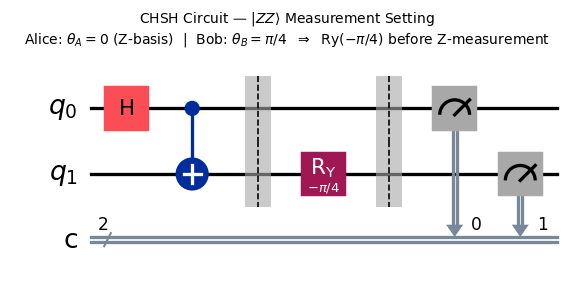

  Saved -> 'chsh_circuit_ZZ.png'


In [15]:
# SECTION 6 — Plot A: Circuit Diagram (ZZ setting)
# ----------------------------------------------------------------------------
# The ZZ circuit: Alice doesn't rotate (θ_A = 0),
# only Bob applies Ry(−π/4) before measuring.
# --------------------------------------------------------------------------------
 
print("\n  CIRCUIT DIAGRAM -")
 
fig_circ, ax_circ = plt.subplots(figsize=(9, 3))
fig_circ.patch.set_facecolor('white')
 
circuits['ZZ'].draw(
    output='mpl',
    ax=ax_circ,
    style='iqp',       # IBM Quantum Platform colour scheme
    fold=-1,           # keep circuit on one line
    plot_barriers=True,
)
ax_circ.set_title(
    r"CHSH Circuit — $|ZZ\rangle$ Measurement Setting"
    "\n"
    r"Alice: $\theta_A = 0$ (Z-basis)  |  "
    r"Bob: $\theta_B = \pi/4$  $\Rightarrow$  Ry$(-\pi/4)$ before Z-measurement",
    fontsize=10, pad=10,
)
fig_circ.tight_layout()
fig_circ.savefig('chsh_circuit_ZZ.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved -> 'chsh_circuit_ZZ.png'")


  CHSH SUMMARY CHART -


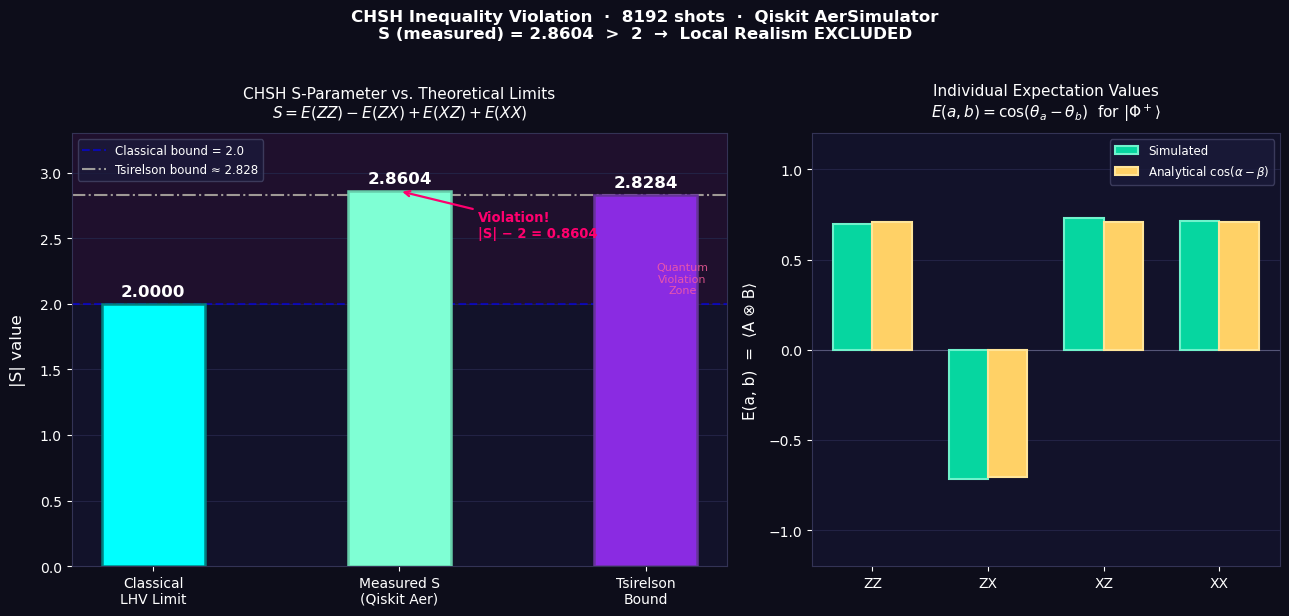

  Saved → 'chsh_svalue_chart.png'

  All done! 


In [16]:
# SECTION 7 — Plot B: S-value & Individual Expectation Values
# --------------------------------------------------------------------------------
 
print("\n  CHSH SUMMARY CHART -")
 
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [1.4, 1]},)
BG    = '#0d0d1a'
PANEL = '#12122a'
fig.patch.set_facecolor(BG)
 
# Left panel: S-value bar chart 
 
ax_left.set_facecolor(PANEL)
 
bar_names   = ['Classical\nLHV Limit', 'Measured S\n(Qiskit Aer)', 'Tsirelson\nBound']
bar_values  = [S_classical, abs(S_measured), S_tsirelson]
bar_colors  = ['aqua', 'aquamarine', 'blueviolet']
bar_edges   = ['teal', 'mediumaquamarine', 'rebeccapurple']
 
bars = ax_left.bar(
    bar_names, bar_values,
    color=bar_colors, edgecolor=bar_edges,
    linewidth=1.8, width=0.42, zorder=3,
)

for bar, val in zip(bars, bar_values):
    ax_left.text(
        bar.get_x() + bar.get_width() / 2, val + 0.04,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold', color='white',
    )
# Reference lines
ax_left.axhline(S_classical, color='blue',  linestyle='--', linewidth=1.5, alpha=0.6, zorder=2, 
                label=f'Classical bound = {S_classical}')
ax_left.axhline(S_tsirelson, color='beige', linestyle='-.', linewidth=1.5, alpha=0.6, zorder=2, 
                label=f'Tsirelson bound ≈ {S_tsirelson:.3f}')
 
# Arrow annotation pointing out the violation
ax_left.annotate(
    f"Violation!\n|S| − 2 = {abs(S_measured) - 2:.4f}",
    xy=(1, abs(S_measured)),
    xytext=(1.32, abs(S_measured) - 0.35),
    fontsize=9.5, color='#ff006e', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#ff006e', lw=1.6),
)
 
# Shade the "quantum violation zone" (S > 2)
ax_left.axhspan(S_classical, 3.3, alpha=0.06, color='#ff006e', zorder=0)
ax_left.text(2.15, 2.08, 'Quantum\nViolation\nZone', fontsize=8, color='#ff5fa0', alpha=0.8, 
             ha='center')
 
ax_left.set_ylim(0, 3.3)
ax_left.set_ylabel('|S| value', color='white', fontsize=12, labelpad=10)
ax_left.set_title(
    'CHSH S-Parameter vs. Theoretical Limits\n'
    r'$S = E(ZZ) - E(ZX) + E(XZ) + E(XX)$',
    color='white', fontsize=11, pad=12,
)
ax_left.tick_params(colors='white', labelsize=10)
for spine in ax_left.spines.values():
    spine.set_edgecolor('#333355')
ax_left.yaxis.grid(True, color='#222244', linewidth=0.8, zorder=0)
ax_left.set_axisbelow(True)
ax_left.legend(fontsize=8.5, facecolor='#1a1a3a', edgecolor='#444466', labelcolor='white', 
               loc='upper left')
 
# Right panel: individual E(a,b) values
 
ax_right.set_facecolor(PANEL)
e_labels = list(E.keys())
e_sim    = [E[k] for k in e_labels]
e_theory = [np.cos(SETTINGS[k][0] - SETTINGS[k][1]) for k in e_labels]
x_pos    = np.arange(len(e_labels))
width    = 0.34
 
ax_right.bar(x_pos - width / 2, e_sim, width, label='Simulated', color='#06d6a0', edgecolor='#70f2cc',
             linewidth=1.5, zorder=3)
ax_right.bar(x_pos + width / 2, e_theory, width, label=r'Analytical $\cos(\alpha-\beta)$', 
             color='#ffd166', edgecolor='#ffe599', linewidth=1.5, zorder=3)
 
ax_right.axhline(0, color='#555577', linewidth=0.8)
ax_right.set_xticks(x_pos)
ax_right.set_xticklabels(e_labels, color='white', fontsize=11)
ax_right.set_ylim(-1.2, 1.2)
ax_right.set_ylabel('E(a, b)  =  ⟨A ⊗ B⟩', color='white', fontsize=11, labelpad=8)
ax_right.set_title(
    'Individual Expectation Values\n'
    r'$E(a,b) = \cos(\theta_a - \theta_b)$  for $|\Phi^+\rangle$',
    color='white', fontsize=11, pad=12,
)
ax_right.tick_params(colors='white', labelsize=10)
for spine in ax_right.spines.values():
    spine.set_edgecolor('#333355')
ax_right.yaxis.grid(True, color='#222244', linewidth=0.8, zorder=0)
ax_right.set_axisbelow(True)
ax_right.legend(fontsize=8.5, facecolor='#1a1a3a',
                edgecolor='#444466', labelcolor='white', loc='upper right')
 
fig.suptitle(
    f'CHSH Inequality Violation  ·  {SHOTS} shots  ·  Qiskit AerSimulator\n'
    f'S (measured) = {S_measured:.4f}  >  2  →  Local Realism EXCLUDED',
    color='white', fontsize=12, y=1.02, fontweight='bold',
)
plt.tight_layout()
fig.savefig('chsh_svalue_chart.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("  Saved → 'chsh_svalue_chart.png'")
print("\n  All done! ")